# Flow Matching Visualization

Interactive notebook to visualize the denoising process in Pi0.5 flow matching.

Shows:
- Input images and task prompt
- Intermediate action states at any timestep t
- 3D trajectory evolution from noise to clean actions

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import sys
sys.path.insert(0, '/mnt/efs/rohingarg/cri/openpi/src')
sys.path.insert(0, '/mnt/efs/rohingarg/cri/openpi')

from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, HTML
import ipywidgets as widgets

# Import utilities from our script
from scripts.viz_flow_matching import (
    load_sample_direct,
    load_model,
    prepare_observation_from_sample,
    sample_actions_with_intermediates,
    plot_3d_trajectory,
    plot_heatmap,
    get_data_root,
    load_metadata,
    load_tasks,
    # New visualization functions
    visualize_action_on_image,
    visualize_denoising_on_image,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
print("Imports loaded!")

## Configuration

Set your config and checkpoint path here:

In [2]:
# Configuration
CONFIG_NAME = "pi05_bridge"
CHECKPOINT_DIR = "../checkpoints/pi05_bridge/bridge_run1_20k/19999"
NUM_DENOISING_STEPS = 10
SEED = 42

## Load Model and Dataset

In [3]:
# Load model (this is the slow part - only needs to happen once)
print(f"Loading model from: {CHECKPOINT_DIR}")
model, config = load_model(CONFIG_NAME, CHECKPOINT_DIR)
print("Model loaded!")

Loading model from: ../checkpoints/pi05_bridge/bridge_run1_20k/19999
Model loaded!


In [4]:
# Fast: Just verify data root exists (no heavy loading!)
data_root = get_data_root()
info = load_metadata(data_root)
print(f"Dataset: {data_root}")
print(f"Total episodes: {info['total_episodes']}")
print(f"Total frames: {info['total_frames']}")
print(f"FPS: {info['fps']}")

Dataset: /mnt/efs/rohingarg/cri/bridge_orig_lerobot
Total episodes: 53192
Total frames: 1893026
FPS: 5


## Helper Functions

In [5]:
# Helper function to run denoising with intermediates
def run_denoising(sample, num_steps=10, seed=42):
    """Prepare observation and run denoising, returning intermediate states."""
    observation = prepare_observation_from_sample(sample, CONFIG_NAME)
    intermediates = sample_actions_with_intermediates(
        model, observation, jax.random.key(seed), num_steps=num_steps
    )
    return intermediates

## Visualization Functions

In [6]:
# Visualization functions (plot_3d_trajectory and plot_heatmap are imported)

def show_input_images(sample):
    """Display the input images and prompt."""
    images = sample["images"]
    n_images = len(images)
    
    fig, axes = plt.subplots(1, max(n_images, 1), figsize=(5*n_images, 5))
    if n_images == 1:
        axes = [axes]
    
    for i, (key, img) in enumerate(images.items()):
        axes[i].imshow(img)
        axes[i].set_title(key)
        axes[i].axis('off')
    
    fig.suptitle(f'Task: "{sample["prompt"]}"', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_timestep(intermediates, t_value):
    """Show visualization for a specific timestep."""
    times = [inter["t"] for inter in intermediates]
    idx = np.argmin(np.abs(np.array(times) - t_value))
    inter = intermediates[idx]
    
    fig = plt.figure(figsize=(14, 5))
    
    ax1 = fig.add_subplot(121, projection='3d')
    color = plt.cm.coolwarm(1 - inter["t"])
    plot_3d_trajectory(inter["x"], ax1, f"t={inter['t']:.2f}", color=color)
    ax1.set_xlim(-3, 3)
    ax1.set_ylim(-3, 3)
    ax1.set_zlim(-3, 3)
    
    ax2 = fig.add_subplot(122)
    im = plot_heatmap(inter["x"], ax2, f"Action Heatmap at t={inter['t']:.2f}")
    plt.colorbar(im, ax=ax2, label='Value')
    
    plt.tight_layout()
    plt.show()

def show_evolution(intermediates, timesteps=[1.0, 0.5, 0.2, 0.0]):
    """Show evolution at multiple timesteps."""
    n = len(timesteps)
    fig = plt.figure(figsize=(5*n, 10))
    
    times = [inter["t"] for inter in intermediates]
    
    for i, t_val in enumerate(timesteps):
        idx = np.argmin(np.abs(np.array(times) - t_val))
        inter = intermediates[idx]
        
        ax1 = fig.add_subplot(2, n, i+1, projection='3d')
        color = plt.cm.coolwarm(1 - inter["t"])
        plot_3d_trajectory(inter["x"], ax1, f"t={inter['t']:.2f}", color=color)
        ax1.set_xlim(-3, 3)
        ax1.set_ylim(-3, 3)
        ax1.set_zlim(-3, 3)
        
        ax2 = fig.add_subplot(2, n, n+i+1)
        plot_heatmap(inter["x"], ax2, f"t={inter['t']:.2f}")
    
    plt.suptitle('Flow Matching Denoising: Noise -> Clean', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_variance_plot(intermediates):
    """Show variance reduction during denoising."""
    times = [inter["t"] for inter in intermediates]
    variances = [np.var(inter["x"][0, :, :7]) for inter in intermediates]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(times, variances, 'b-o', linewidth=2, markersize=8)
    ax.set_xlabel('Time t (1=noise, 0=clean)', fontsize=12)
    ax.set_ylabel('Action Variance', fontsize=12)
    ax.set_title('Variance Reduction During Denoising', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    plt.tight_layout()
    plt.show()

## Load a Sample and Run Inference

Change `SAMPLE_IDX` to explore different samples from the dataset.

Loading episode 0, frame 0...
Loaded! Task: 'put small spoon from basket to tray'


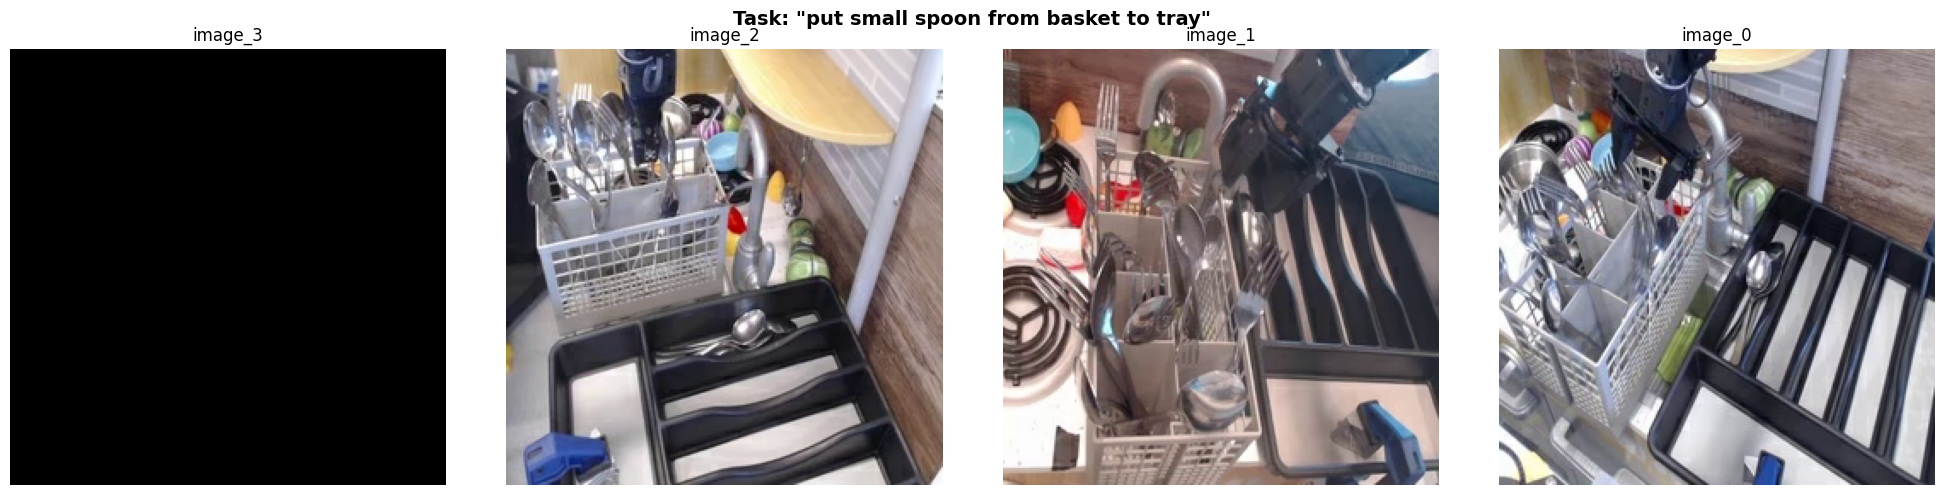

In [7]:
EPISODE_IDX = 0   # Which episode to load
FRAME_IDX = 0     # Which frame within the episode

# Fast direct loading - no LeRobotDataset needed!
print(f"Loading episode {EPISODE_IDX}, frame {FRAME_IDX}...")
sample = load_sample_direct(EPISODE_IDX, FRAME_IDX, action_horizon=config.model.action_horizon)
print(f"Loaded! Task: '{sample['prompt']}'")

# Show input images
show_input_images(sample)

In [8]:
# Run denoising
print(f"Running flow matching with {NUM_DENOISING_STEPS} steps...")
intermediates = run_denoising(sample, num_steps=NUM_DENOISING_STEPS, seed=SEED)
print(f"Captured {len(intermediates)} intermediate states")

Running flow matching with 10 steps...


Captured 11 intermediate states


## Visualize Actions on Images

The key visualization - see the predicted trajectory overlaid on the input images:

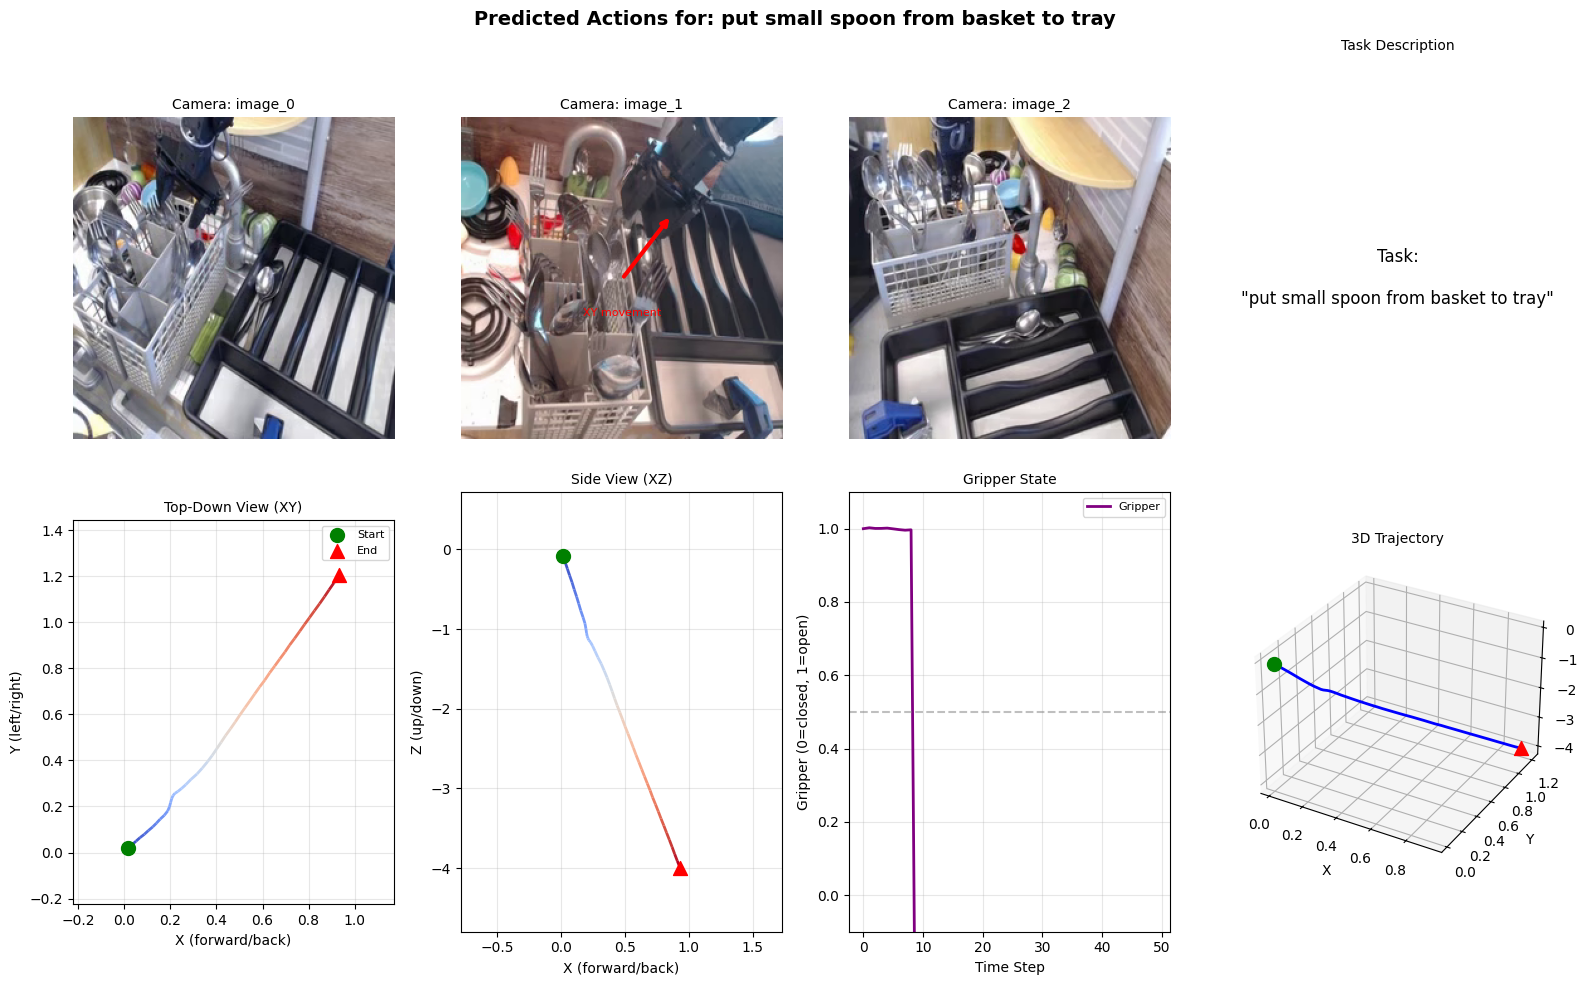

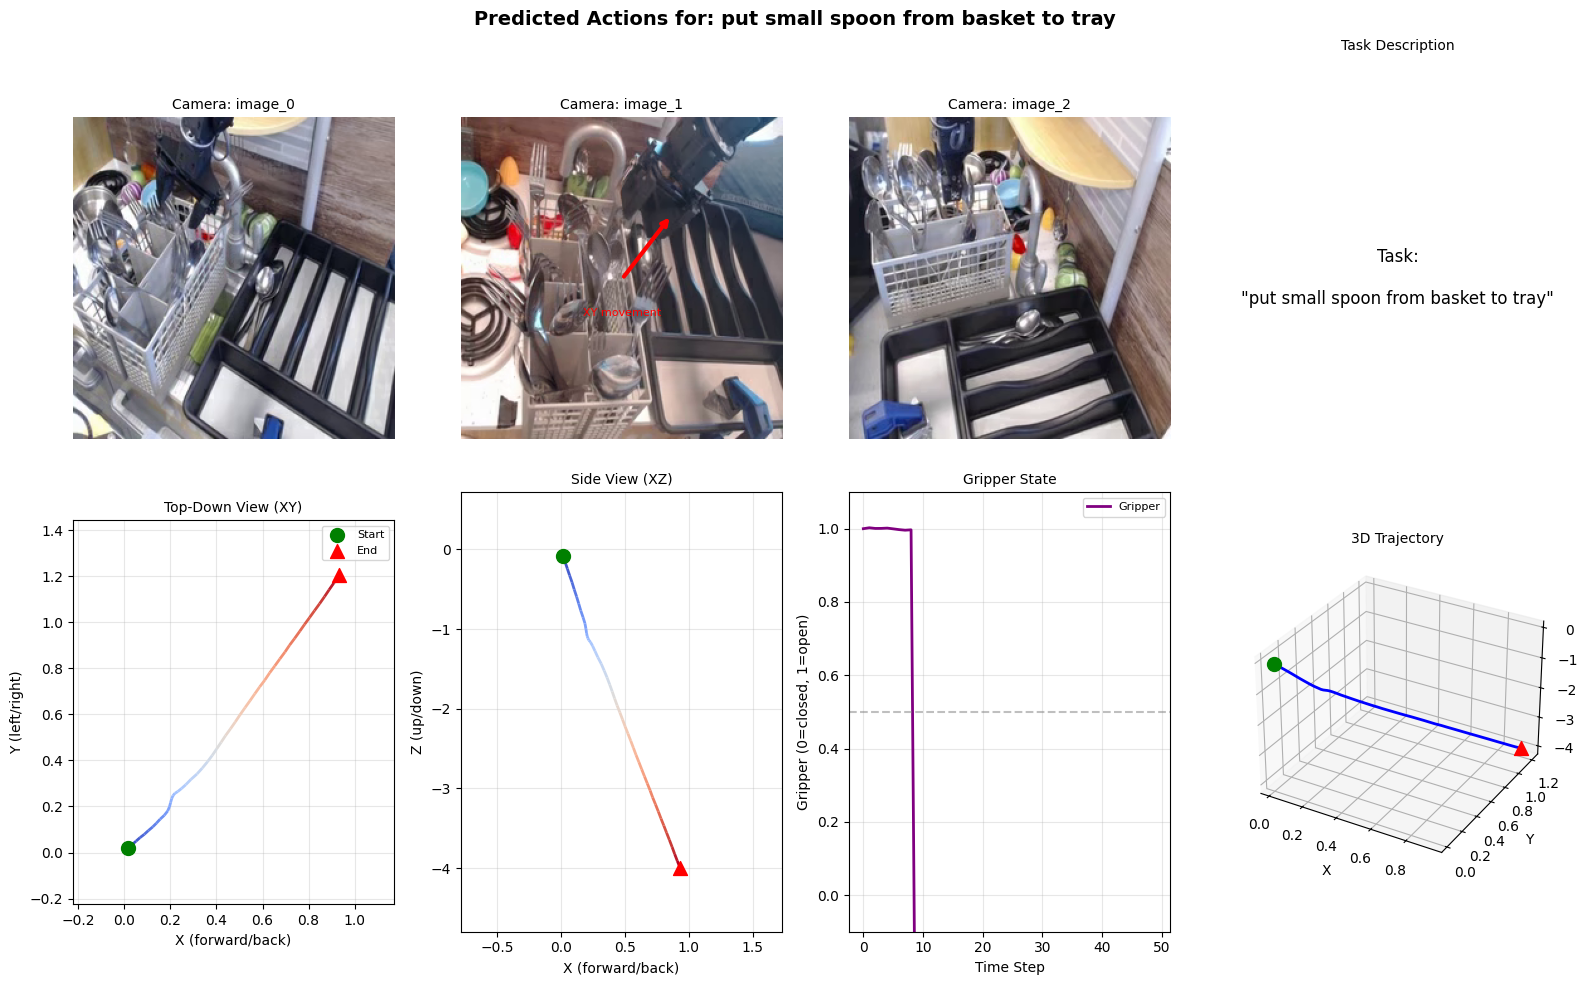

In [ ]:
# Visualize the FINAL predicted actions (t=0) on input images
final_actions = intermediates[-1]["x"]  # t=0.0, clean prediction
visualize_action_on_image(sample, final_actions, title=f"Predicted Actions for: {sample['prompt']}")

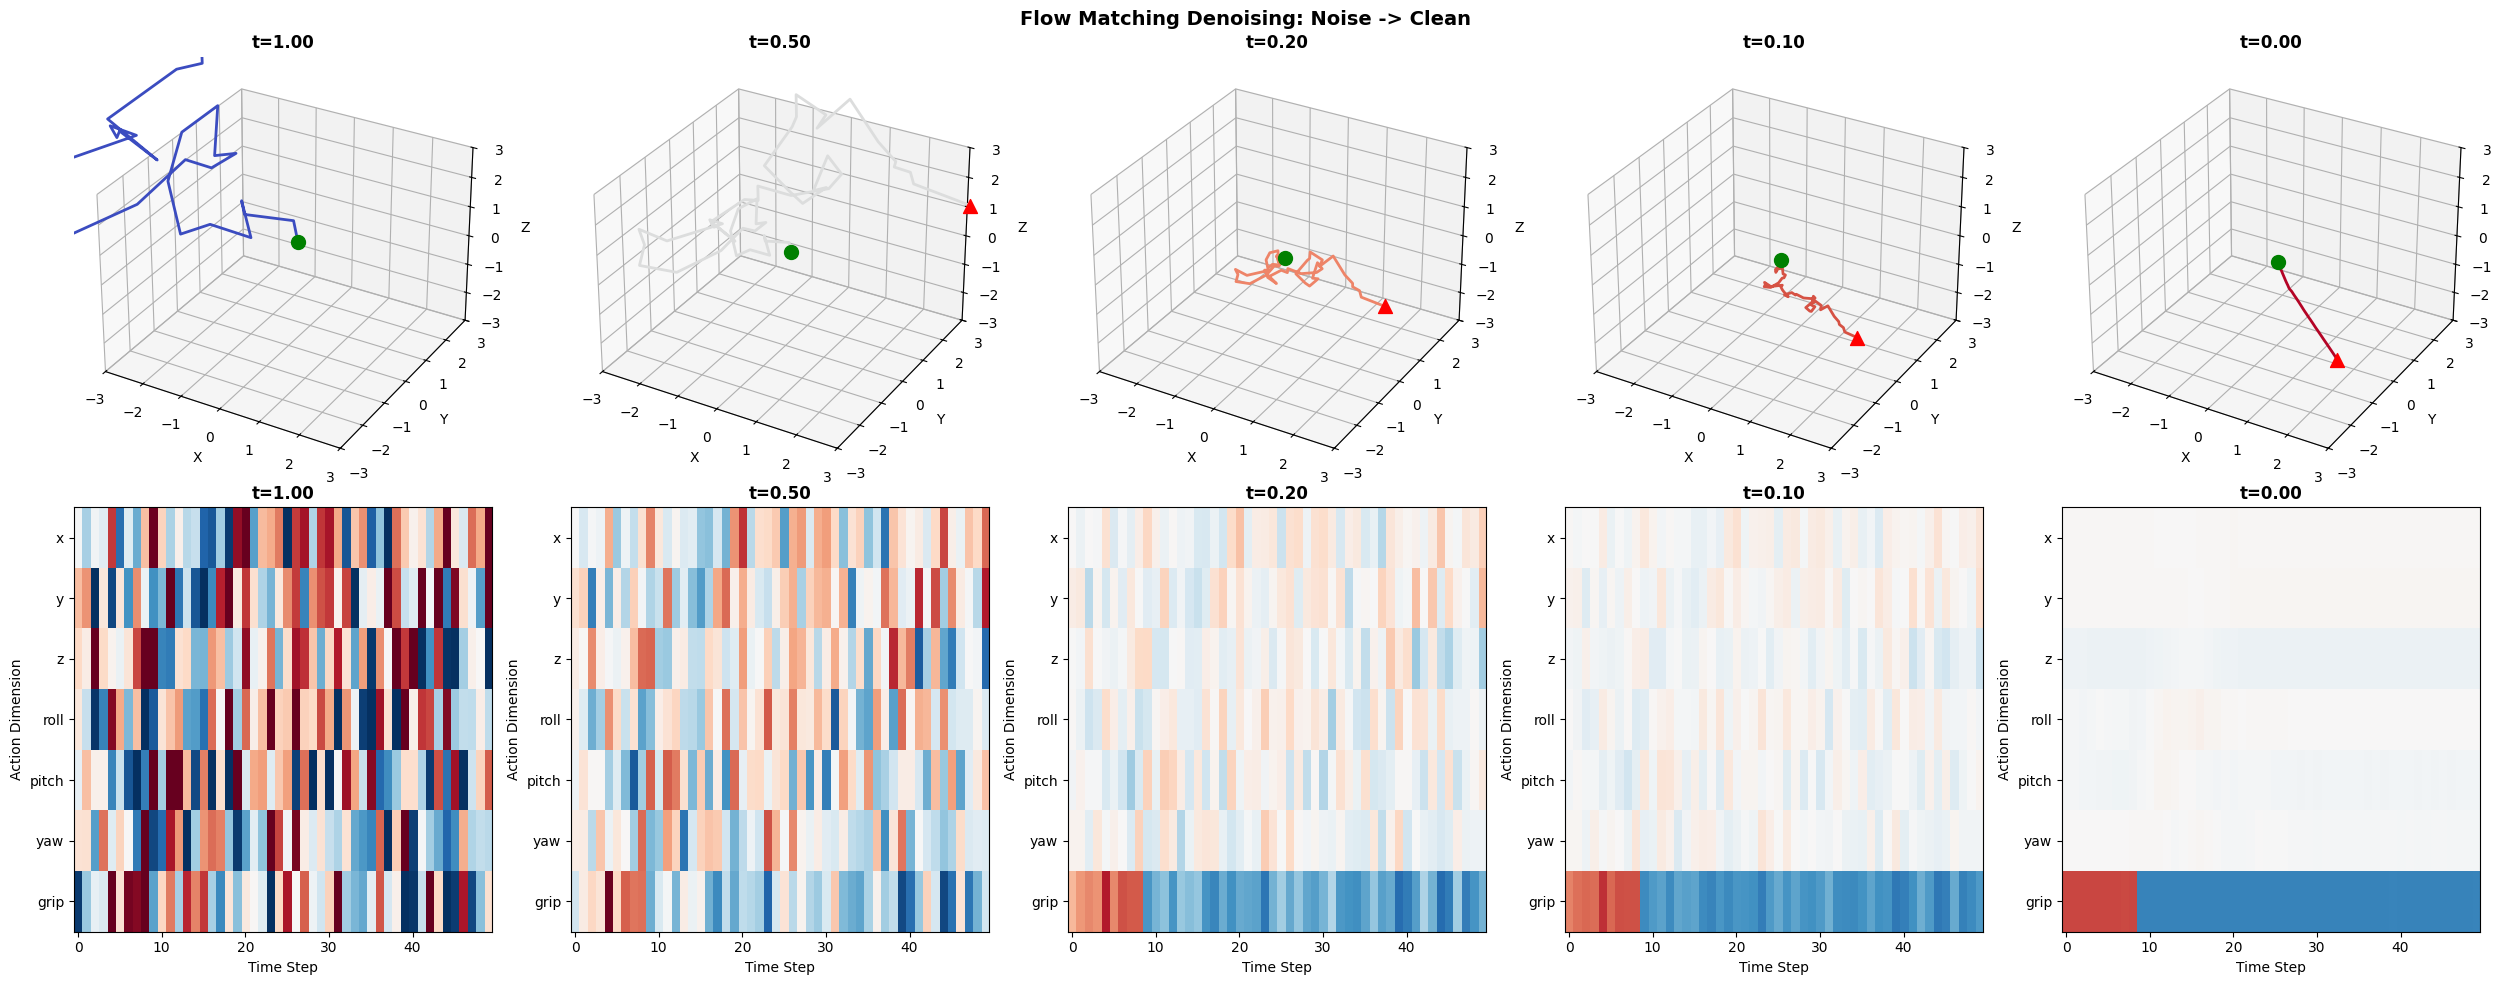

In [ ]:
# Show evolution at key timesteps
show_evolution(intermediates, timesteps=[1.0, 0.5, 0.2, 0.1, 0.0])

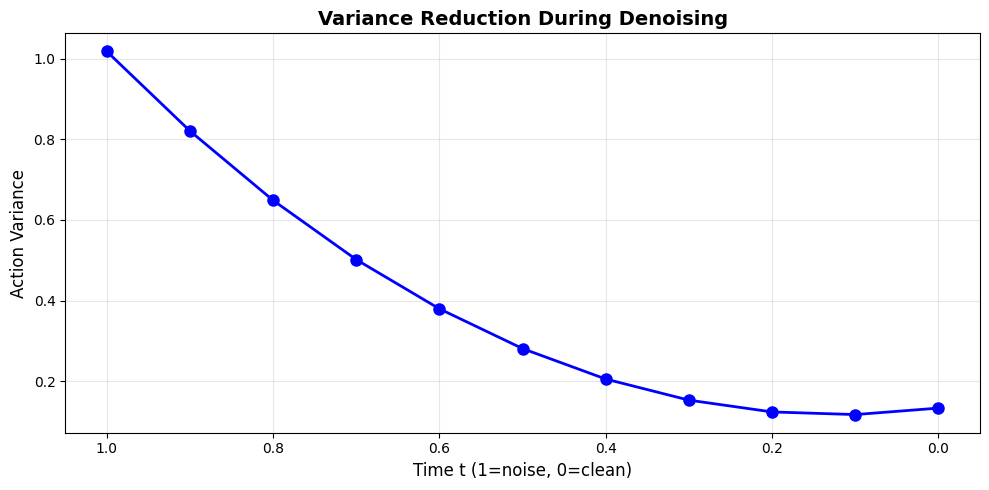

In [12]:
# Show variance reduction
show_variance_plot(intermediates)

## Interactive Timestep Slider

Use the slider to explore any timestep:

In [13]:
# Interactive slider
@widgets.interact(t=widgets.FloatSlider(min=0.0, max=1.0, step=0.1, value=1.0, description='Time t:'))
def interactive_viz(t):
    show_timestep(intermediates, t)

interactive(children=(FloatSlider(value=1.0, description='Time t:', max=1.0), Output()), _dom_classes=('widget…

## Custom Timesteps

Visualize any specific timesteps you want:

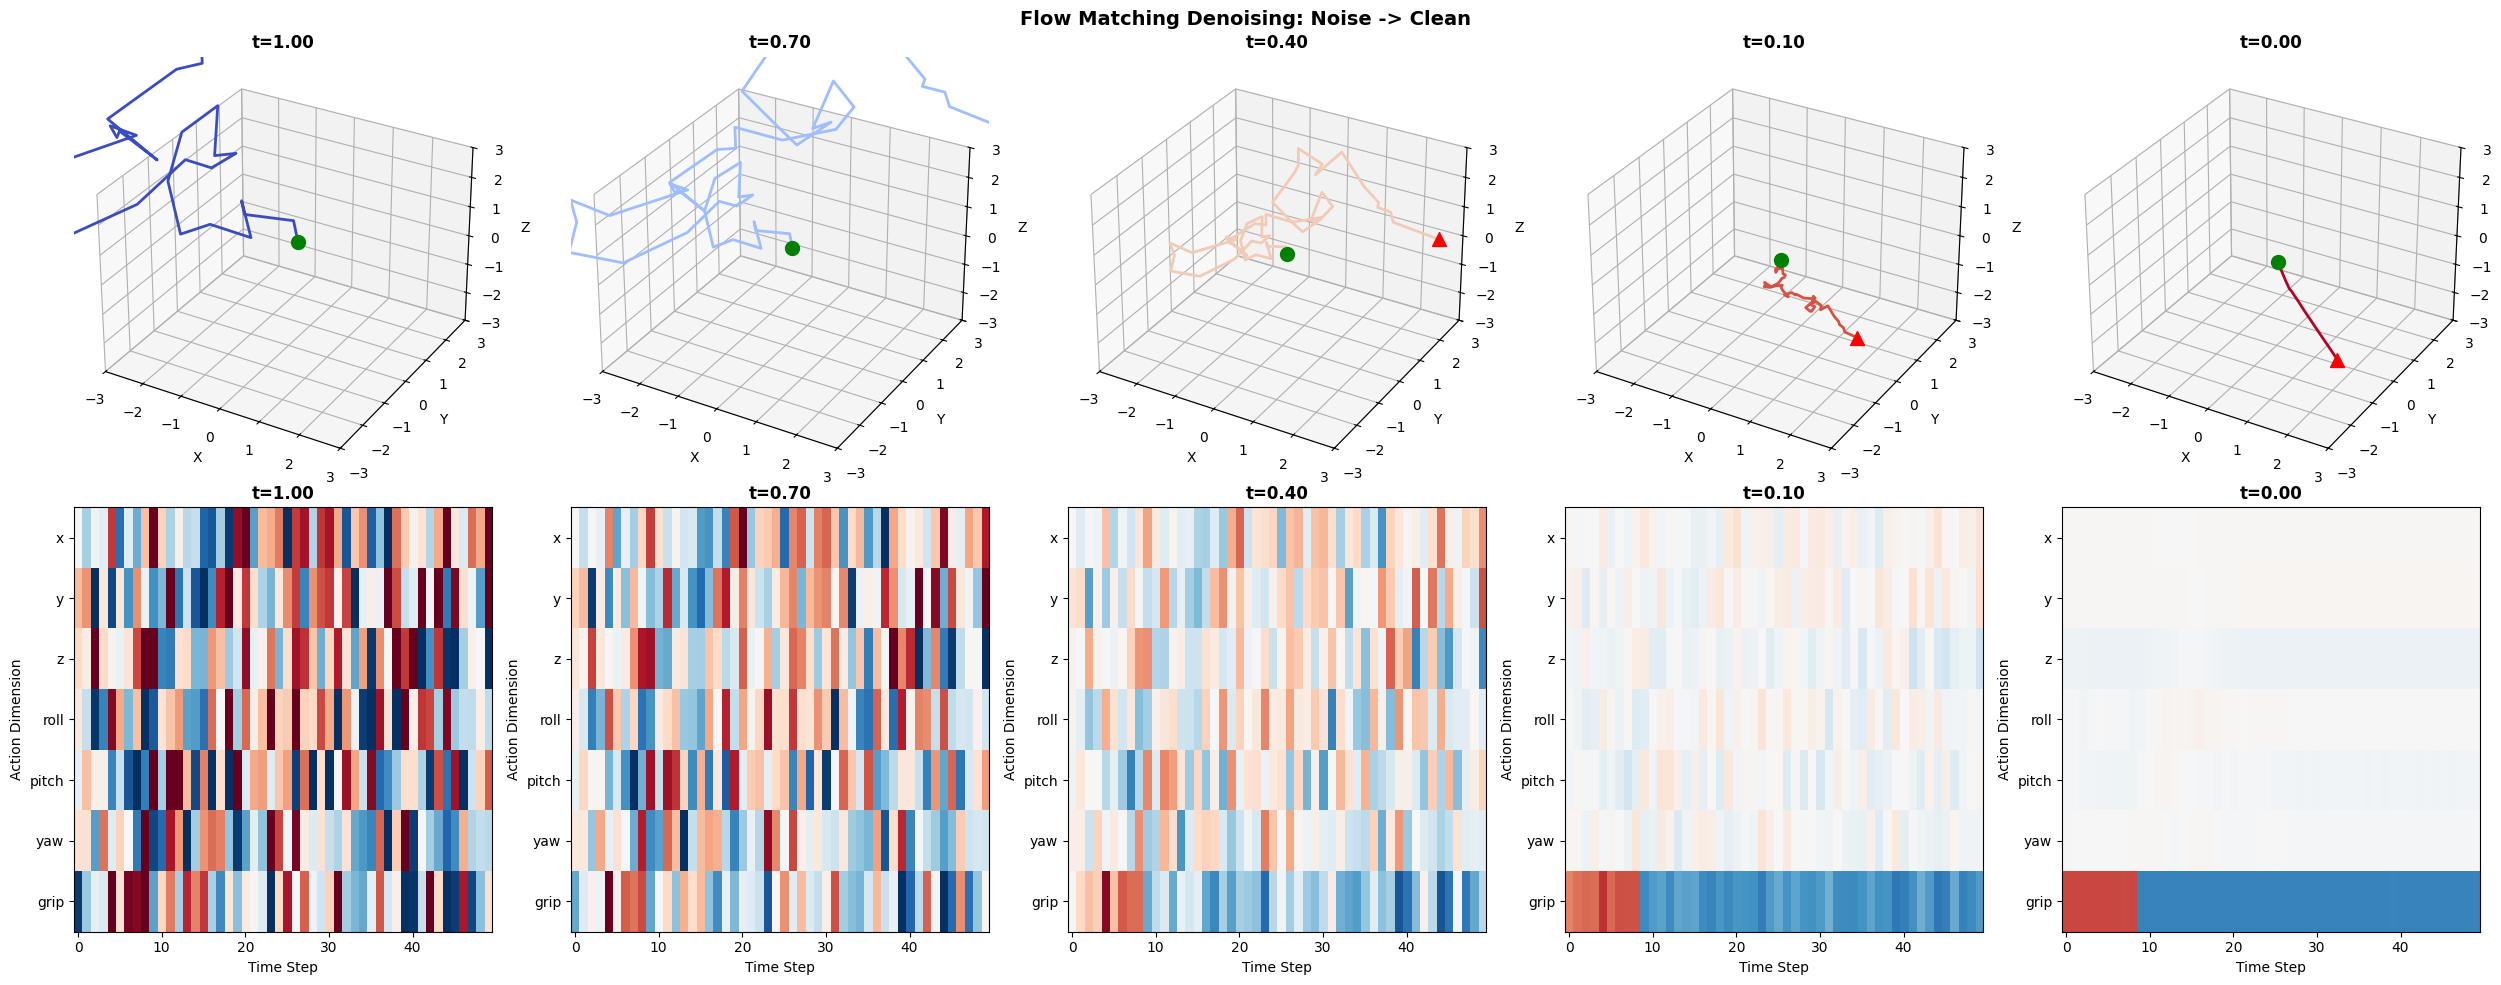

In [14]:
# Custom timesteps - modify this list as needed
custom_timesteps = [1.0, 0.7, 0.4, 0.1, 0.0]
show_evolution(intermediates, timesteps=custom_timesteps)

## Explore Different Samples

Quick function to explore a new sample:

In [15]:
def explore_episode(episode_idx, frame_idx=0, seed=42):
    """Quick function to explore a different episode."""
    print(f"\n{'='*50}")
    print(f"Episode {episode_idx}, Frame {frame_idx}")
    print(f"{'='*50}\n")
    
    sample = load_sample_direct(episode_idx, frame_idx, action_horizon=config.model.action_horizon)
    print(f"Task: '{sample['prompt']}'")
    show_input_images(sample)
    
    inters = run_denoising(sample, num_steps=NUM_DENOISING_STEPS, seed=seed)
    show_evolution(inters, timesteps=[1.0, 0.5, 0.2, 0.0])
    return sample, inters

# Example: explore episode 100
# sample_100, inters_100 = explore_episode(100)